# T45 — pySCION Phanerozoic biogeochemistry on a reconstructed paleo-Earth

**Run pySCION (the pythonic SCION Earth-evolution model of Merdith et al. (2025, *Science Advances*)) through the Phanerozoic, plot 16 of its core time-series organised into four titled 2×2 grids (climate state, atmospheric chemistry, biogeochemical fluxes, isotope tracers), and overlay reconstructed paleo-Earth snapshots at three CO₂-inflection ages.**

## What this notebook produces

Five visually distinct figure blocks:

- **SET 1 — Climate state (2×2).** pCO₂, global SAT, iceline paleolatitude, sea-level fraction.
- **SET 2 — Atmospheric chemistry + redox (2×2).** pO₂, ocean anoxia fraction, vegetation evolution, atmosphere+ocean C reservoir.
- **SET 3 — Biogeochemical fluxes (2×2).** Marine organic-C burial, land organic-C burial, carbonate weathering, silicate weathering.
- **SET 4 — Isotope tracers (2×2).** δ¹³C of A reservoir, δ¹³C of marine carbonate burial, δ¹³C of organic-C burial, δ³⁴S of S reservoir.
- **SET 5 — Paleo-Earth snapshots** at three CO₂-inflection ages (default 250, 100, 30 Ma), with Scotese-Wright PaleoDEMs overlain when available locally.

Every panel y-axis auto-fits to the actual data extent (no hardcoded ranges that crop the data).

## Why Scotese & Wright 2018

We use the Scotese & Wright (2018) plate model here (anchor plate 0) because it also drives the Scotese & Wright PaleoDEMs that we overlay on the snapshots — same kinematic framework, so the reconstructed continents and the paleo-elevations land on each other rather than drifting apart. Mixing plate models across the reconstruction and the raster (e.g. Merdith 2021 reconstruction + Scotese-Wright PaleoDEMs) produces visible mis-registration and should be avoided.

**Audience:** postgrad.   **Difficulty:** ★★★.

## Learning objectives

- Run pySCION end-to-end from a notebook and recover its `Run_class` output (which contains `state`, `forcings`, `gridstate`, ...).
- Render four themed 2×2 time-series grids with auto-fit y-axes.
- Overlay forward-modelled climate state on reconstructed paleo-Earth maps at scientifically-chosen inflection ages.

## Prerequisites and runtime

- Plate model: Scotese & Wright 2018 (matches the PaleoDEMs we overlay).
- Python: `gplately`, `pygmt`, `pygplates`, `numpy`, `pandas`, `xarray`, `matplotlib`.
- **pySCION**: not on PyPI. Default expects embedded copy at `./external/pySCION/` (or any other local pySCION clone — override via the `PYSCION_REPO` env var).
- Optional: Scotese-Wright PaleoDEMs at `PALEODEM_DIR`.
- Runtime: pySCION ~10–30 s; all five rendering blocks ~10 s total.


*Reference:* <https://github.com/amer7632/pySCION>

## Data availability

| Asset | Provenance | Where to get it |
|---|---|---|
| **pySCION** | Merdith et al. (2025, *Science Advances*) — embedded at `./external/pySCION/` (or any other local pySCION clone — override via the `PYSCION_REPO` env var) | Standalone: [Zenodo 7940113](https://zenodo.org/record/7940113). |
| **Scotese & Wright 2018** rotation model | EarthByte / Plate Model Manager | Auto-downloaded by `plate_model_manager` (`scotese_and_wright2018`). |
| **Scotese & Wright 2018 PaleoDEMs** (optional) | Earthbyte / Christopher Scotese / Nicky M. Wright | [paleodem-resource-scotese-and-wright-2018](https://www.earthbyte.org/paleodem-resource-scotese-and-wright-2018/). |


In [1]:
# Defensive cwd fix
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Imports
import os, sys
import numpy as np, pandas as pd, xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
import gplately, pygmt, pygplates
from plate_model_manager import PlateModelManager
from IPython.display import display, HTML
try:
    print(f"gplately {gplately.__version__}  pygmt {pygmt.__version__}  pygplates {pygplates.__version__}")
except Exception as _e:
    print(f"version probe failed: {_e}")


gplately 2.0.0  pygmt v0.19.0  pygplates 1.0.0


## Configuration

In [2]:
# === USER CONFIGURATION =====================================================
PYSCION_REPO = os.environ.get(
    "PYSCION_REPO",
    str(Path("./external/pySCION")),
)
PALEODEM_DIR = os.environ.get(
    "PALEODEM_DIR",
    str(Path("./external/PaleoDEMs_Scotese_Wright_2018")),
)
MODEL_NAME           = "scotese_and_wright2018"   # matches the Scotese-Wright PaleoDEMs we overlay
ANCHOR_PLATE_ID      = 0
# Three Phanerozoic CO2-inflection ages to overlay snapshots on
INFLECTION_TIMES_MA  = (250.0, 100.0, 30.0)
# pySCION run mode: -1 = production, 0 = tuning, 1 = sensitivity
PYSCION_RUNCONTROL   = -1
# ============================================================================


## 1. Run pySCION through the Phanerozoic

In [3]:
# run pySCION
repo = Path(PYSCION_REPO).expanduser().resolve()
if not (repo / "pySCION_initialise.py").exists():
    raise FileNotFoundError(
        f"Could not find pySCION at {repo!r}.\n"
        "Set PYSCION_REPO env var (or edit CONFIGURATION cell) to point at\n"
        "your local pySCION checkout. Default expects pySCION embedded\n"
        "at a local pySCION clone.\n"
        "Standalone download: Zenodo 7940113.")
sys.path.insert(0, str(repo))
_prev_cwd = os.getcwd()
os.chdir(repo)
try:
    import pySCION_initialise
    import matplotlib.pyplot as _plt
    # Suppress pySCION's built-in 4×4 diagnostic panel — its tiny fonts
    # make it unreadable in the rendered notebook, and the four 2×2 SETs
    # below cover exactly the same state variables with legible labels
    # and auto-fit y-ranges. Monkey-patch plt.show during the call so
    # any explicit show() inside pySCION is a no-op, then close every
    # figure it leaves open before Jupyter's inline backend can capture
    # them into cell output.
    _orig_show = _plt.show
    _plt.show = lambda *a, **kw: None
    try:
        # pySCION_initialise returns a SINGLE Run_class object with
        # .state (+ .forcings, .gridstate, .pars, ...) as attributes.
        run   = pySCION_initialise.pySCION_initialise(PYSCION_RUNCONTROL)
        state = (run[0] if isinstance(run, tuple) else run).state  # amer7632 pySCION returns (run, interpstack, lipstack)
    finally:
        _plt.show = _orig_show
        _plt.close("all")
finally:
    os.chdir(_prev_cwd)

# Time axis (Ma, positive into the past)
age = np.abs(np.asarray(state.time).flatten()) / 1e6  # pySCION state.time is in years -> Ma

# Series extraction helper — tolerant of missing attrs AND of 2D arrays.
# Several State_class attributes (iceline, sat_equator, sat_tropical,
# possibly others in newer pySCION versions) are 2D: zonal-band × time.
# A blind .flatten() would mismatch len(age). Strategy:
#   - 1D, length matches age: use as-is.
#   - 2D with one dim matching len(age): mean over the other dim.
#   - anything else: return all-NaN of length(age) so plotting still works.
def _series(name, scale=1.0):
    arr = getattr(state, name, None)
    if arr is None:
        return np.full(len(age), np.nan)
    arr = np.asarray(arr)
    n = len(age)
    if arr.ndim == 1 and arr.size == n:
        return arr * scale
    if arr.ndim == 2:
        if arr.shape[0] == n:
            return arr.mean(axis=1) * scale
        if arr.shape[1] == n:
            return arr.mean(axis=0) * scale
    # Last-resort: flatten and resample/return NaN
    flat = arr.flatten()
    if flat.size == n:
        return flat * scale
    return np.full(n, np.nan)

# Climate state
co2       = _series("rco2", 280.0)                      # ppmv
sat       = _series("temperature") - 273.15             # °C
iceline   = _series("iceline")                          # paleolat
psea      = _series("psea")                             # sea level
# Atmospheric chemistry + redox
o2_pct    = _series("ro2", 21.0)                        # %
anox      = _series("anox")                             # fraction
evo       = _series("evo")                              # PAL-like
A_res     = _series("A")                                # mol C
# Biogeochemical fluxes
mocb      = _series("mocb")                             # mol C/yr
locb      = _series("locb")                             # mol C/yr
carbw     = _series("carbw")                            # mol C/yr
silw      = _series("silw")                             # mol C/yr
# Isotopes
d13c_A    = _series("d13c_A")                           # ‰
delta_C   = _series("delta_C")                          # ‰ organic
delta_mccb= _series("delta_mccb")                       # ‰ marine carb burial
d34s_S    = _series("d34s_S")                           # ‰

def _rng(arr):
    if not np.any(np.isfinite(arr)):
        return "<no data>"
    return f"{np.nanmin(arr):.3g} – {np.nanmax(arr):.3g}"

print(f"  pySCION run window: {age.min():.0f} – {age.max():.0f} Ma  ({len(age)} steps)")
for n, a in [("pCO2 ppmv", co2), ("SAT °C", sat), ("iceline lat", iceline),
             ("psea", psea), ("pO2 %", o2_pct), ("anox frac", anox),
             ("evo PAL", evo), ("A reservoir mol C", A_res),
             ("MOCB mol C/yr", mocb), ("LOCB mol C/yr", locb),
             ("carbw mol C/yr", carbw), ("silw mol C/yr", silw),
             ("d13c_A ‰", d13c_A), ("delta_C ‰", delta_C),
             ("delta_mccb ‰", delta_mccb), ("d34s_S ‰", d34s_S)]:
    print(f"    {n:24s} {_rng(a)}")

# Auto-fit y-axis helper: tight bounds around actual data extent.
def _autoy(ax, data, pad_frac=0.05, log=False):
    finite = np.asarray(data)[np.isfinite(data)]
    if finite.size == 0:
        return
    lo, hi = float(np.min(finite)), float(np.max(finite))
    if log and lo > 0:
        ax.set_yscale("log")
        rng = np.log10(hi) - np.log10(lo)
        pad = rng * pad_frac
        ax.set_ylim(10**(np.log10(lo) - pad), 10**(np.log10(hi) + pad))
    else:
        rng = hi - lo
        if rng == 0:
            rng = max(abs(hi), 1.0)
        pad = rng * pad_frac
        ax.set_ylim(lo - pad, hi + pad)


Arc weathering is turned ON!
Suture weathering is turned ON!
Degassing is turned ON!
Palaeogeography is turned ON!
Plant forcings are turned ON!
LIP weathering is turned ON!
LIP degassing is turned ON!
setting parameters... 8.916854858398438e-05
Done
time: 0.00010132789611816406
loading forcings... 0.00010704994201660156
Done
time: 0.1427922248840332
Beginning run: 



Model step: 200 	 time: -599.0290525518876 	 next keyframe: -540 



Model step: 400 	 time: -564.9090089842279 	 next keyframe: -540 



Model step: 600 	 time: -556.792996053472 	 next keyframe: -540 



Model step: 800 	 time: -552.3341827767747 	 next keyframe: -540 



...

Model step: 5000 	 time: -65.87507734248089 	 next keyframe: -52 



Model step: 5200 	 time: -29.733272526017174 	 next keyframe: -15 



Model step: 5400 	 time: -15.159426860022675 	 next keyframe: -15 

Integration finished 	
Total steps: 5456 	
Output steps: 1137 

assembling   vectors... 	


Done
time: 14.28516411781311


  pySCION run window: 0 – 600 Ma  (1137 steps)
    pCO2 ppmv                278 – 1.44e+04
    SAT °C                   13.1 – 26.3
    iceline lat              45.2 – 90
    psea                     8.65e+09 – 7.95e+10
    pO2 %                    1.65 – 28
    anox frac                3.55e-05 – 0.992
    evo PAL                  0 – 1
    A reservoir mol C        3.18e+18 – 2.29e+19
    MOCB mol C/yr            2.56e+11 – 6.6e+12
    LOCB mol C/yr            0 – 4.21e+12
    carbw mol C/yr           2.38e+12 – 1.28e+13
    silw mol C/yr            2.03e+12 – 1.51e+13
    d13c_A ‰                 -1.29 – 6.99
    delta_C ‰                -2 – 0.755
    delta_mccb ‰             -1.29 – 6.99
    d34s_S ‰                 8.75 – 35


## 2. SET 1 — Climate state (2×2): CO₂ → temperature → ice → sea level

A 2×2 grid: pCO₂ (top-left, log y), global SAT (top-right), iceline paleolatitude (bottom-left), sea-level fraction (bottom-right). All four panels share `Age (Ma)` on the x-axis with the present on the right.


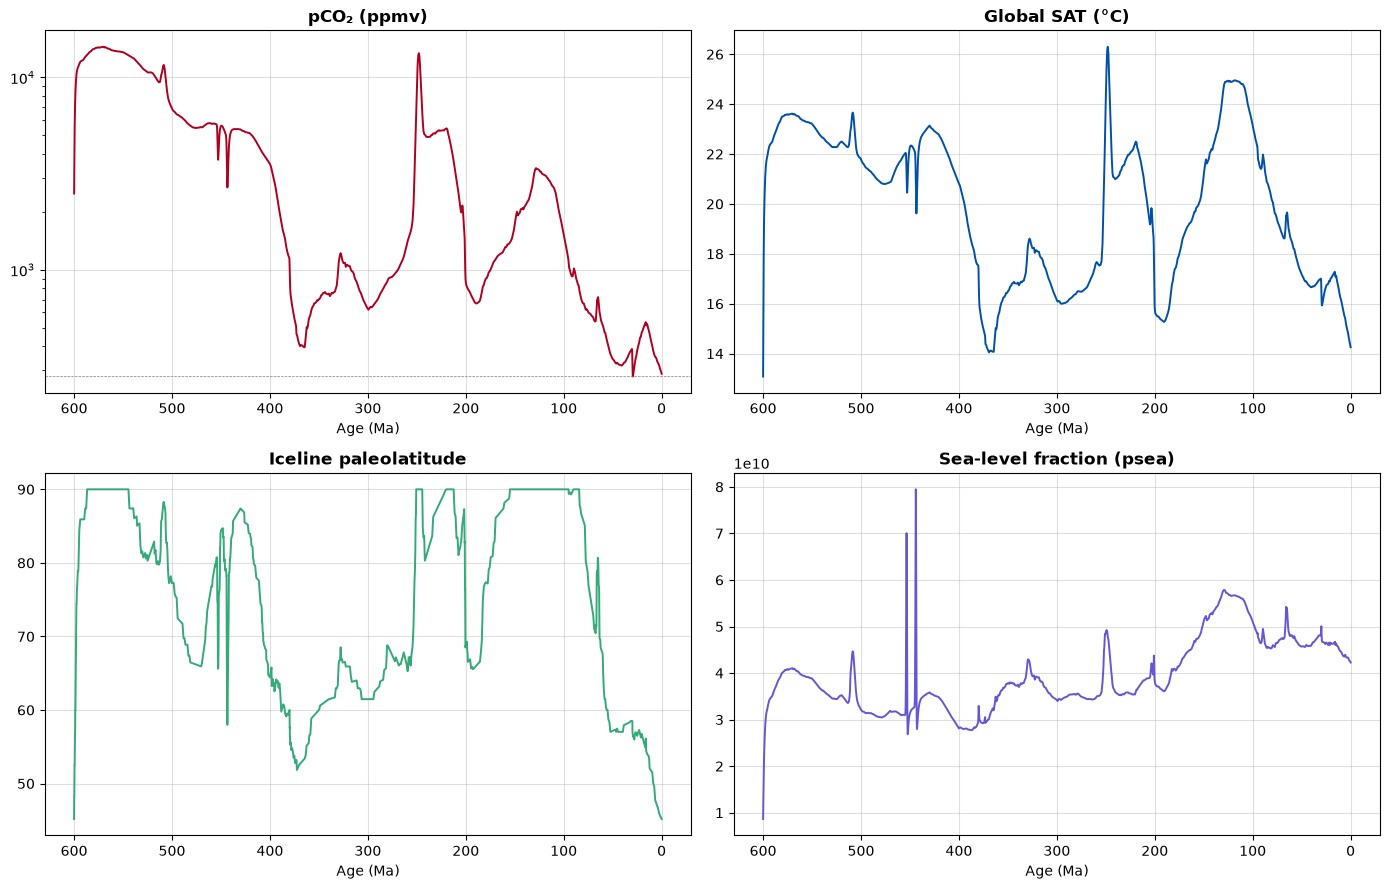

In [4]:
# SET 1: Climate state
display(HTML('<div style="margin-top:1.0cm; padding:0.4em 0.8em; '
              'background:#fff4e6; border-left:5px solid #d9822b; '
              'font-size:14pt; font-weight:bold; '
              'font-family:Helvetica,Arial,sans-serif;">'
              'SET 1 — Climate state'
              '</div>'))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
((a11, a12), (a21, a22)) = axes
a11.plot(age, co2, color="#b00020", lw=1.4)
a11.axhline(280, color="gray", lw=0.5, ls="--")
a11.set_title("pCO\u2082 (ppmv)", fontweight="bold")
_autoy(a11, co2, log=True)
a12.plot(age, sat, color="#0050a8", lw=1.4)
a12.set_title("Global SAT (°C)", fontweight="bold")
_autoy(a12, sat)
a21.plot(age, iceline, color="#3a7", lw=1.4)
a21.set_title("Iceline paleolatitude", fontweight="bold")
_autoy(a21, iceline)
a22.plot(age, psea, color="#6557d3", lw=1.4)
a22.set_title("Sea-level fraction (psea)", fontweight="bold")
_autoy(a22, psea)
for ax in axes.flat:
    ax.set_xlabel("Age (Ma)"); ax.invert_xaxis(); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()
display(HTML('<div style="height:1.2cm"></div>'))


## 3. SET 2 — Atmospheric chemistry + redox (2×2)

A 2×2 grid: atmospheric O₂ (% atm; top-left), ocean anoxia fraction (top-right), vegetation evolution PAL-like factor (bottom-left), and the bulk atmosphere+ocean carbon reservoir A in mol C (bottom-right).


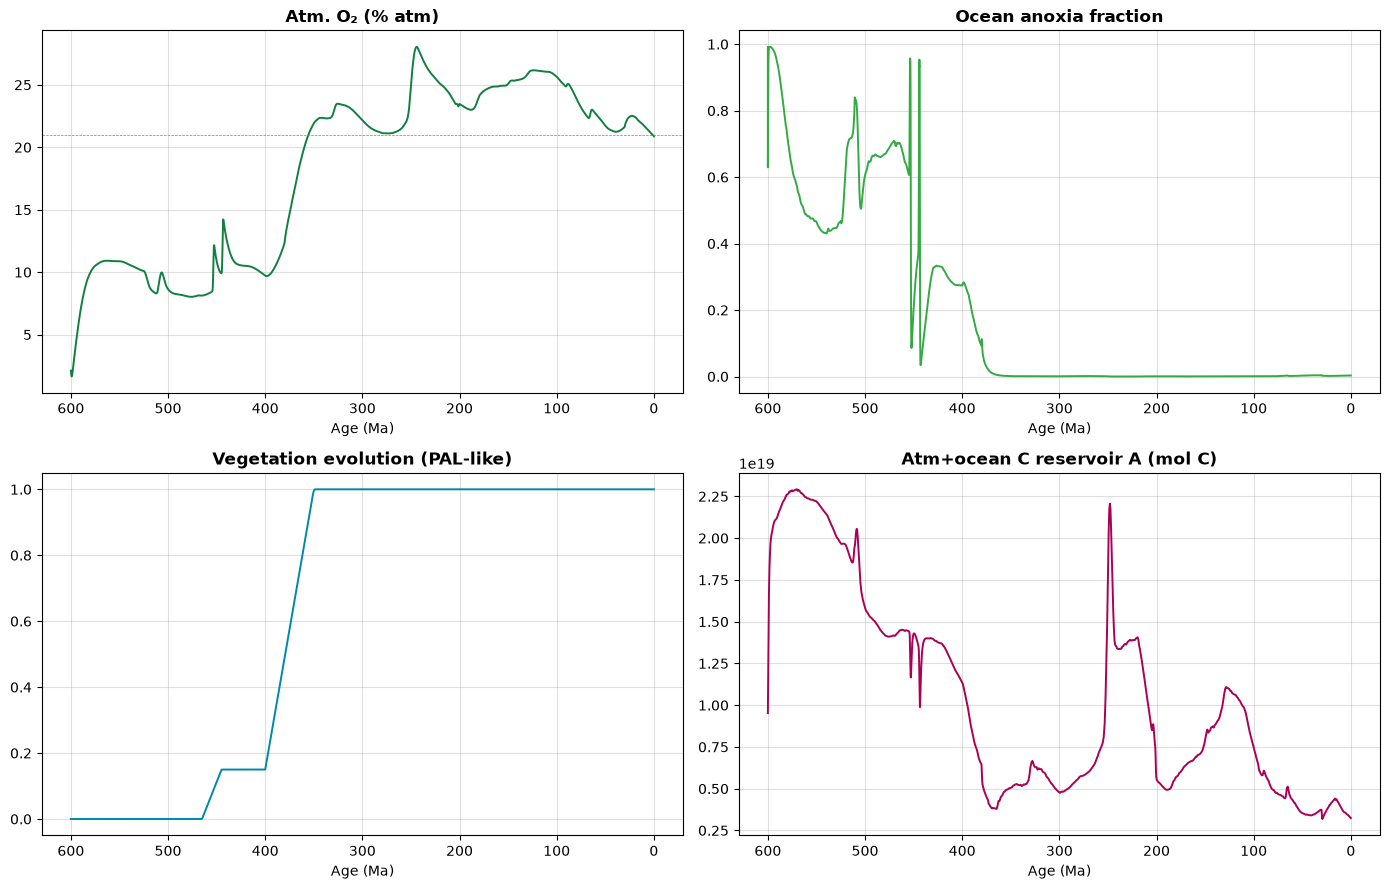

In [5]:
# SET 2: Atmospheric chemistry + redox
display(HTML('<div style="margin-top:1.0cm; padding:0.4em 0.8em; '
              'background:#e8f0fe; border-left:5px solid #4a6fa5; '
              'font-size:14pt; font-weight:bold; '
              'font-family:Helvetica,Arial,sans-serif;">'
              'SET 2 — Atmospheric chemistry + redox'
              '</div>'))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
((a11, a12), (a21, a22)) = axes
a11.plot(age, o2_pct, color="#108040", lw=1.4)
a11.axhline(21.0, color="gray", lw=0.5, ls="--")
a11.set_title("Atm. O\u2082 (% atm)", fontweight="bold")
_autoy(a11, o2_pct)
a12.plot(age, anox, color="#3a4", lw=1.4)
a12.set_title("Ocean anoxia fraction", fontweight="bold")
_autoy(a12, anox)
a21.plot(age, evo, color="#08a", lw=1.4)
a21.set_title("Vegetation evolution (PAL-like)", fontweight="bold")
_autoy(a21, evo)
a22.plot(age, A_res, color="#a05", lw=1.4)
a22.set_title("Atm+ocean C reservoir A (mol C)", fontweight="bold")
_autoy(a22, A_res)
for ax in axes.flat:
    ax.set_xlabel("Age (Ma)"); ax.invert_xaxis(); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()
display(HTML('<div style="height:1.2cm"></div>'))


## 4. SET 3 — Biogeochemical fluxes (2×2)

A 2×2 grid of the four headline biogeochemical fluxes (mol C / yr): marine organic-C burial (MOCB; top-left), land organic-C burial (LOCB; top-right), carbonate weathering (bottom-left), silicate weathering (bottom-right). MOCB-LOCB cross-overs and the silicate-weathering thermostat are the principal signals.


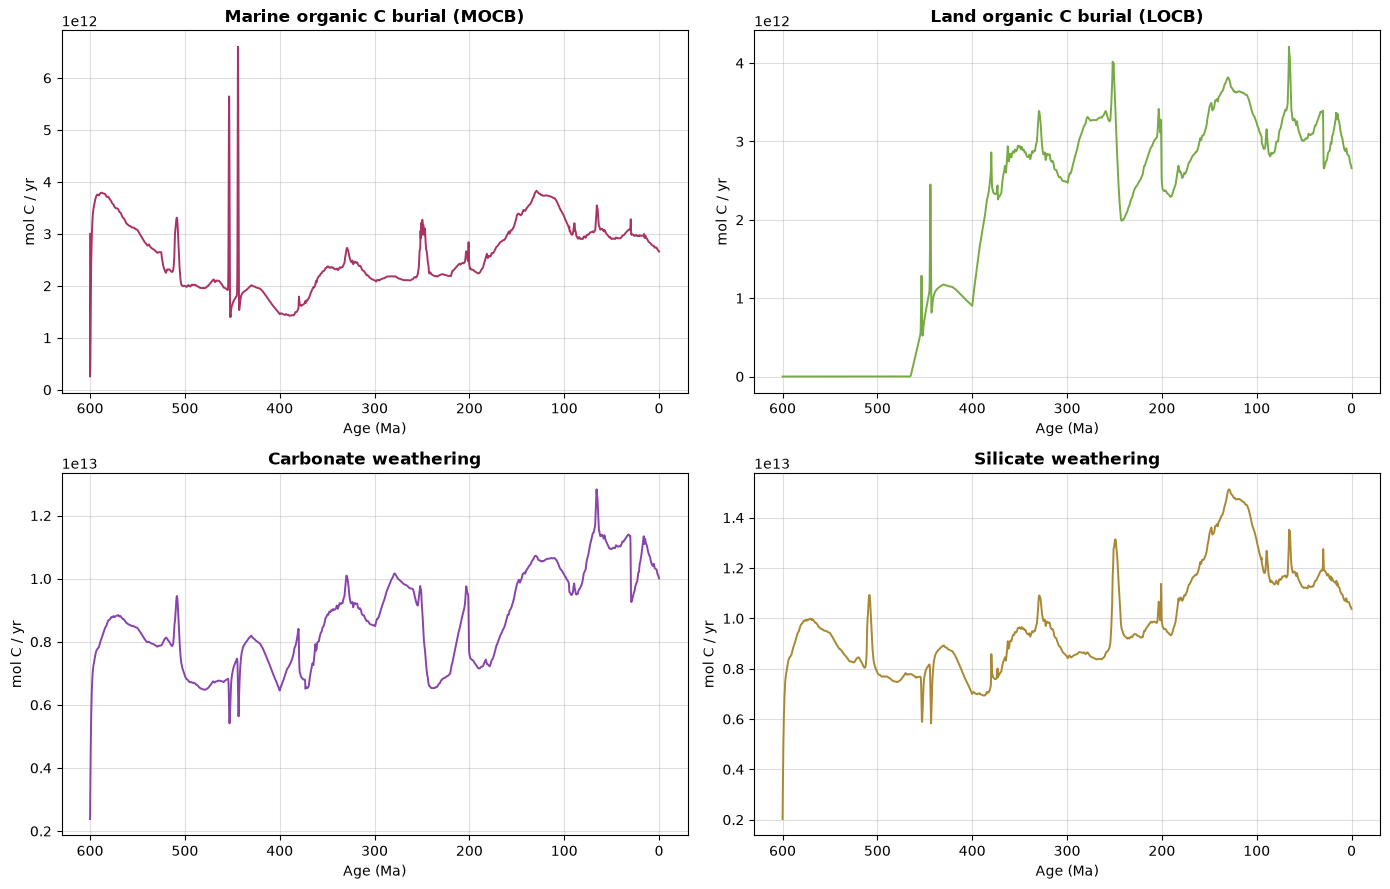

In [6]:
# SET 3: Biogeochemical fluxes
display(HTML('<div style="margin-top:1.0cm; padding:0.4em 0.8em; '
              'background:#eaf5e8; border-left:5px solid #4a9a45; '
              'font-size:14pt; font-weight:bold; '
              'font-family:Helvetica,Arial,sans-serif;">'
              'SET 3 — Biogeochemical fluxes'
              '</div>'))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
((a11, a12), (a21, a22)) = axes
a11.plot(age, mocb, color="#a36", lw=1.4)
a11.set_title("Marine organic C burial (MOCB)", fontweight="bold")
_autoy(a11, mocb)
a12.plot(age, locb, color="#7a4", lw=1.4)
a12.set_title("Land organic C burial (LOCB)", fontweight="bold")
_autoy(a12, locb)
a21.plot(age, carbw, color="#84a", lw=1.4)
a21.set_title("Carbonate weathering", fontweight="bold")
_autoy(a21, carbw)
a22.plot(age, silw, color="#a83", lw=1.4)
a22.set_title("Silicate weathering", fontweight="bold")
_autoy(a22, silw)
for ax in axes.flat:
    ax.set_xlabel("Age (Ma)"); ax.set_ylabel("mol C / yr")
    ax.invert_xaxis(); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()
display(HTML('<div style="height:1.2cm"></div>'))


## 5. SET 4 — Isotope tracers (2×2)

A 2×2 grid of carbon and sulfur isotope tracers: δ¹³C of the bulk atmosphere+ocean reservoir A (top-left), δ¹³C of marine carbonate burial (top-right), δ¹³C of organic-C burial (bottom-left), and δ³⁴S of the sulfur reservoir (bottom-right). All in ‰.


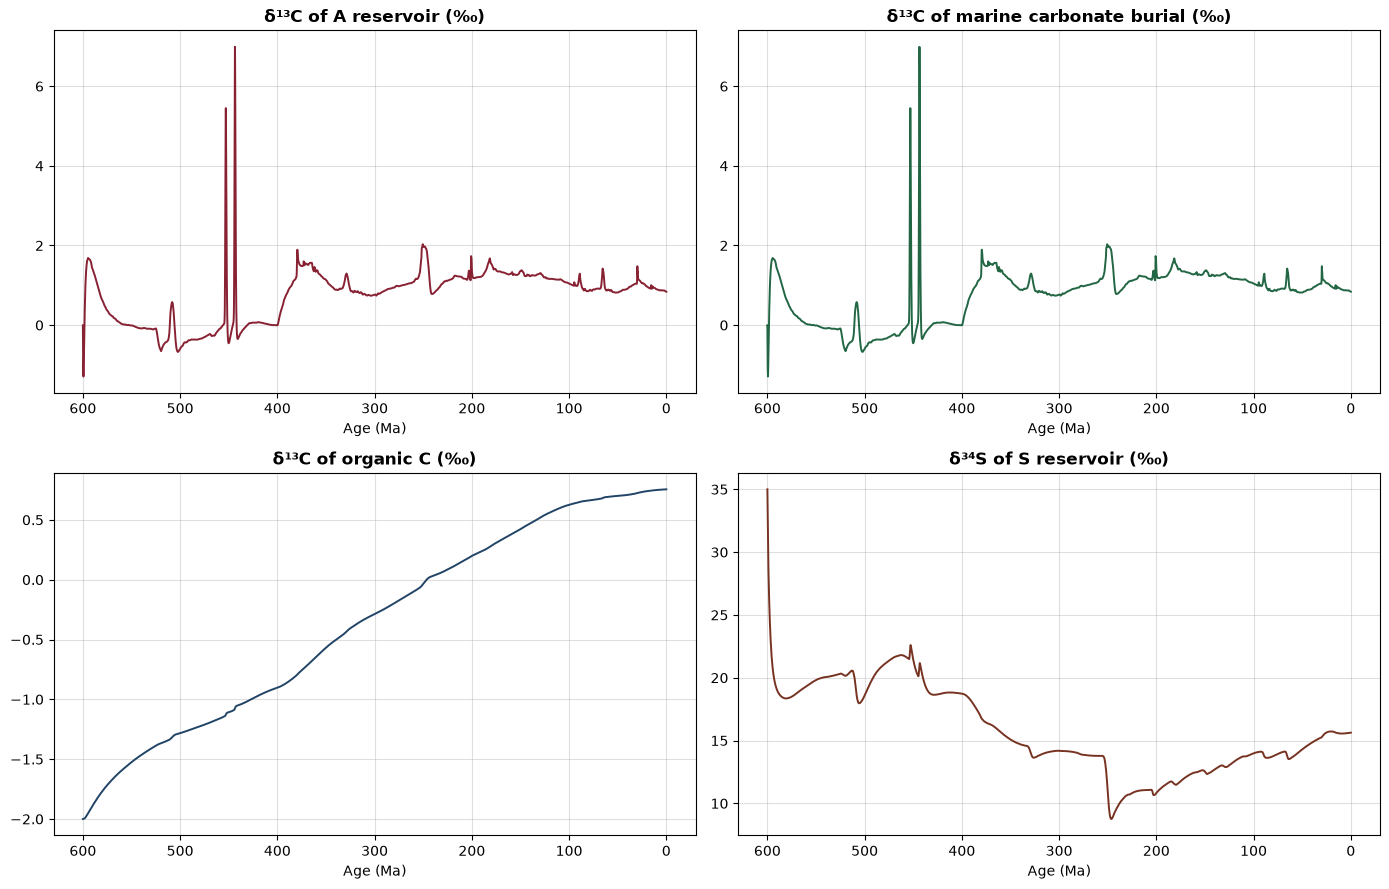

In [7]:
# SET 4: Isotope tracers
display(HTML('<div style="margin-top:1.0cm; padding:0.4em 0.8em; '
              'background:#f4e8f7; border-left:5px solid #7a3f8d; '
              'font-size:14pt; font-weight:bold; '
              'font-family:Helvetica,Arial,sans-serif;">'
              'SET 4 — Isotope tracers'
              '</div>'))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
((a11, a12), (a21, a22)) = axes
a11.plot(age, d13c_A, color="#823", lw=1.4)
a11.set_title("\u03b4\u00b9\u00b3C of A reservoir (\u2030)", fontweight="bold")
_autoy(a11, d13c_A)
a12.plot(age, delta_mccb, color="#264", lw=1.4)
a12.set_title("\u03b4\u00b9\u00b3C of marine carbonate burial (\u2030)", fontweight="bold")
_autoy(a12, delta_mccb)
a21.plot(age, delta_C, color="#246", lw=1.4)
a21.set_title("\u03b4\u00b9\u00b3C of organic C (\u2030)", fontweight="bold")
_autoy(a21, delta_C)
a22.plot(age, d34s_S, color="#732", lw=1.4)
a22.set_title("\u03b4\u00b3\u2074S of S reservoir (\u2030)", fontweight="bold")
_autoy(a22, d34s_S)
for ax in axes.flat:
    ax.set_xlabel("Age (Ma)"); ax.invert_xaxis(); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()
display(HTML('<div style="height:1.2cm"></div>'))


## 6. SET 5 — Paleo-Earth at three CO₂-inflection ages

For each inflection age, render a Mollweide paleo-Earth (Scotese & Wright 2018 plate model) with the Scotese-Wright paleo-DEM overlain when available. **No plate-boundary overlay** — Scotese & Wright 2018 only provides evolving topologies for the last 100 Ma, so drawing boundaries at the older snapshot ages (e.g. 250 Ma) would be empty or misleading. The paleo-DEM alone carries the geographic signal. The in-frame annotation reports the pySCION-modelled pCO₂ at that age, linking the spatial substrate to a single climate-state scalar.


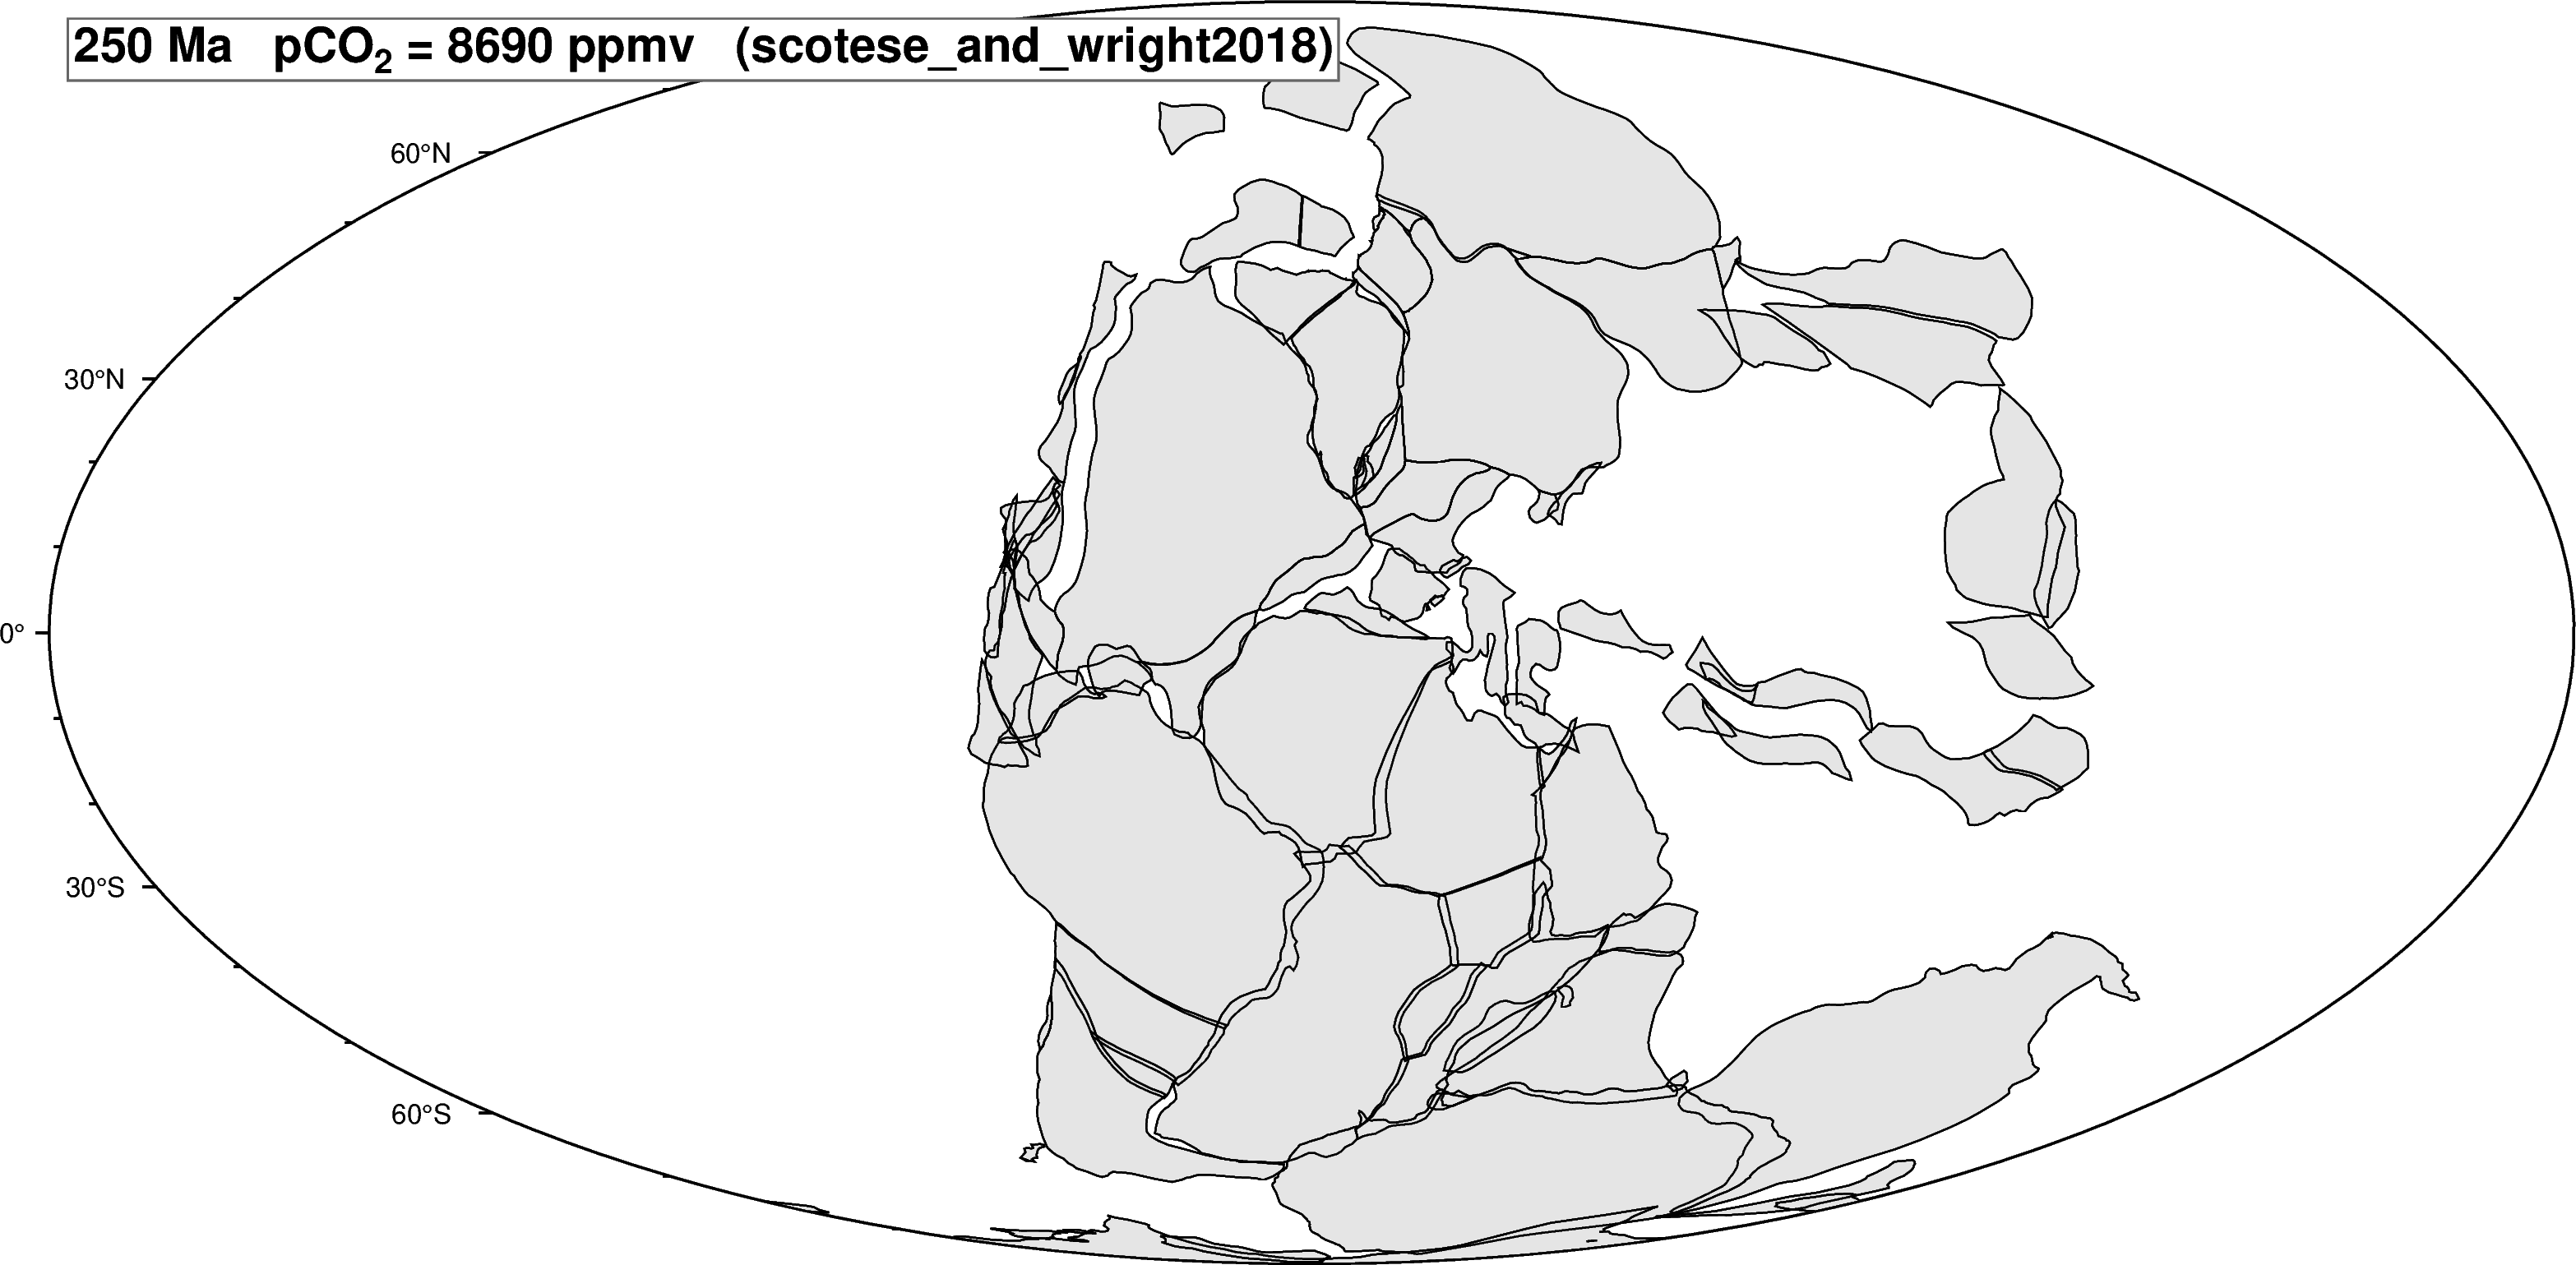

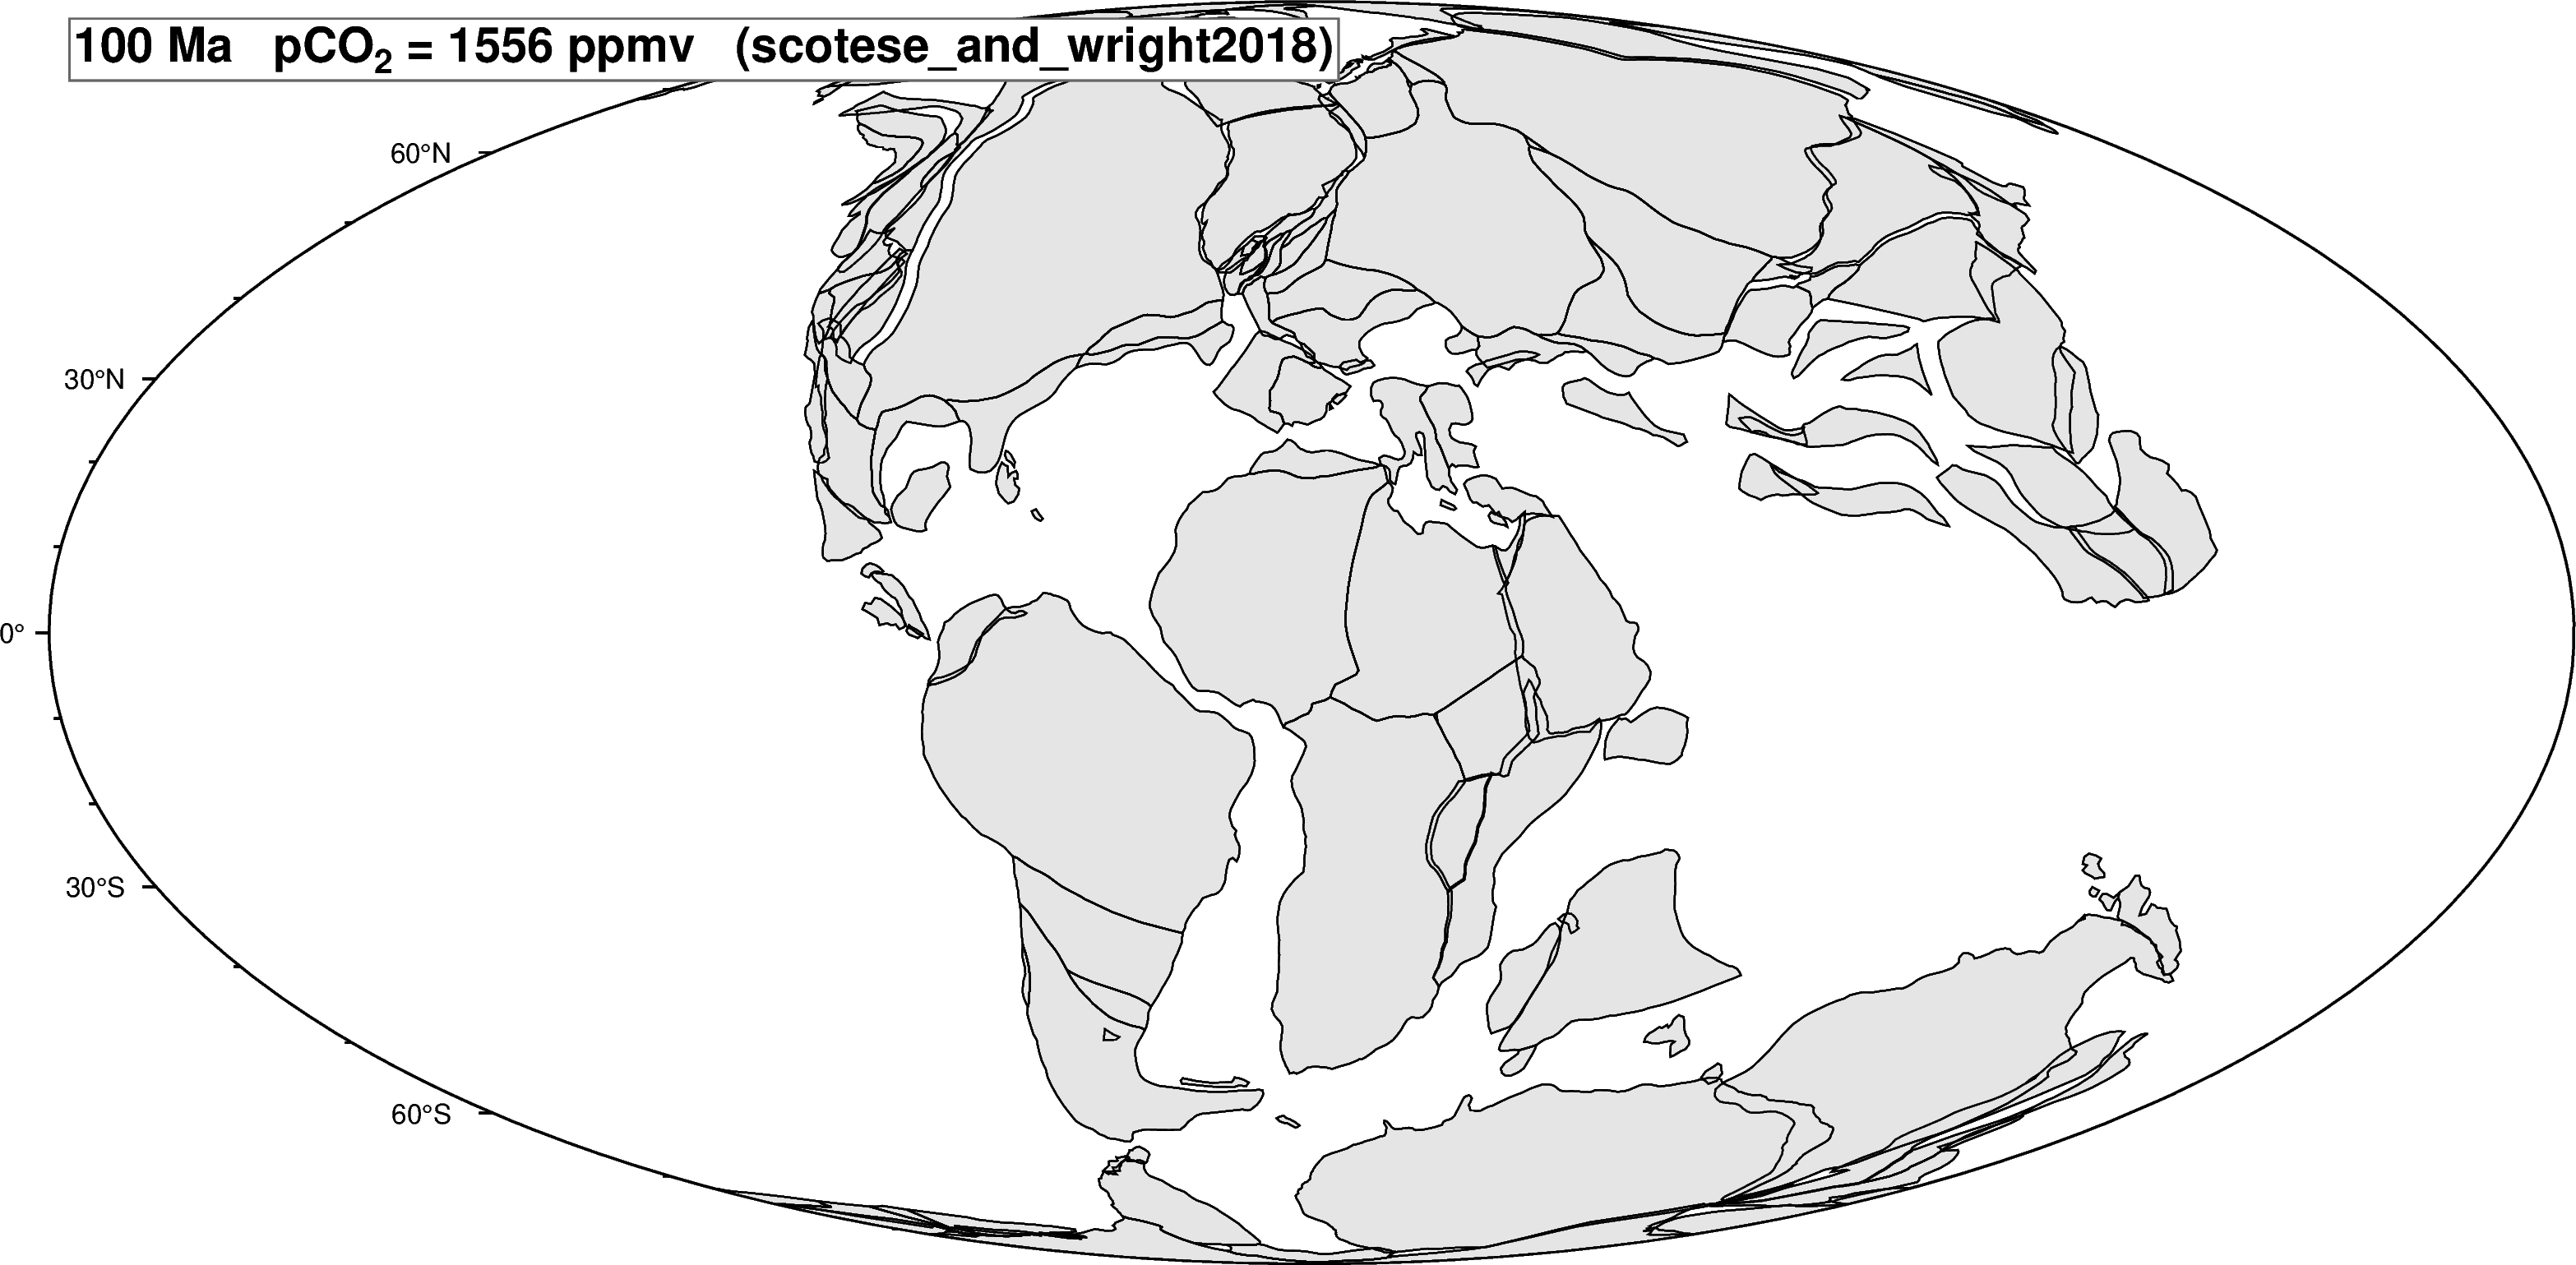

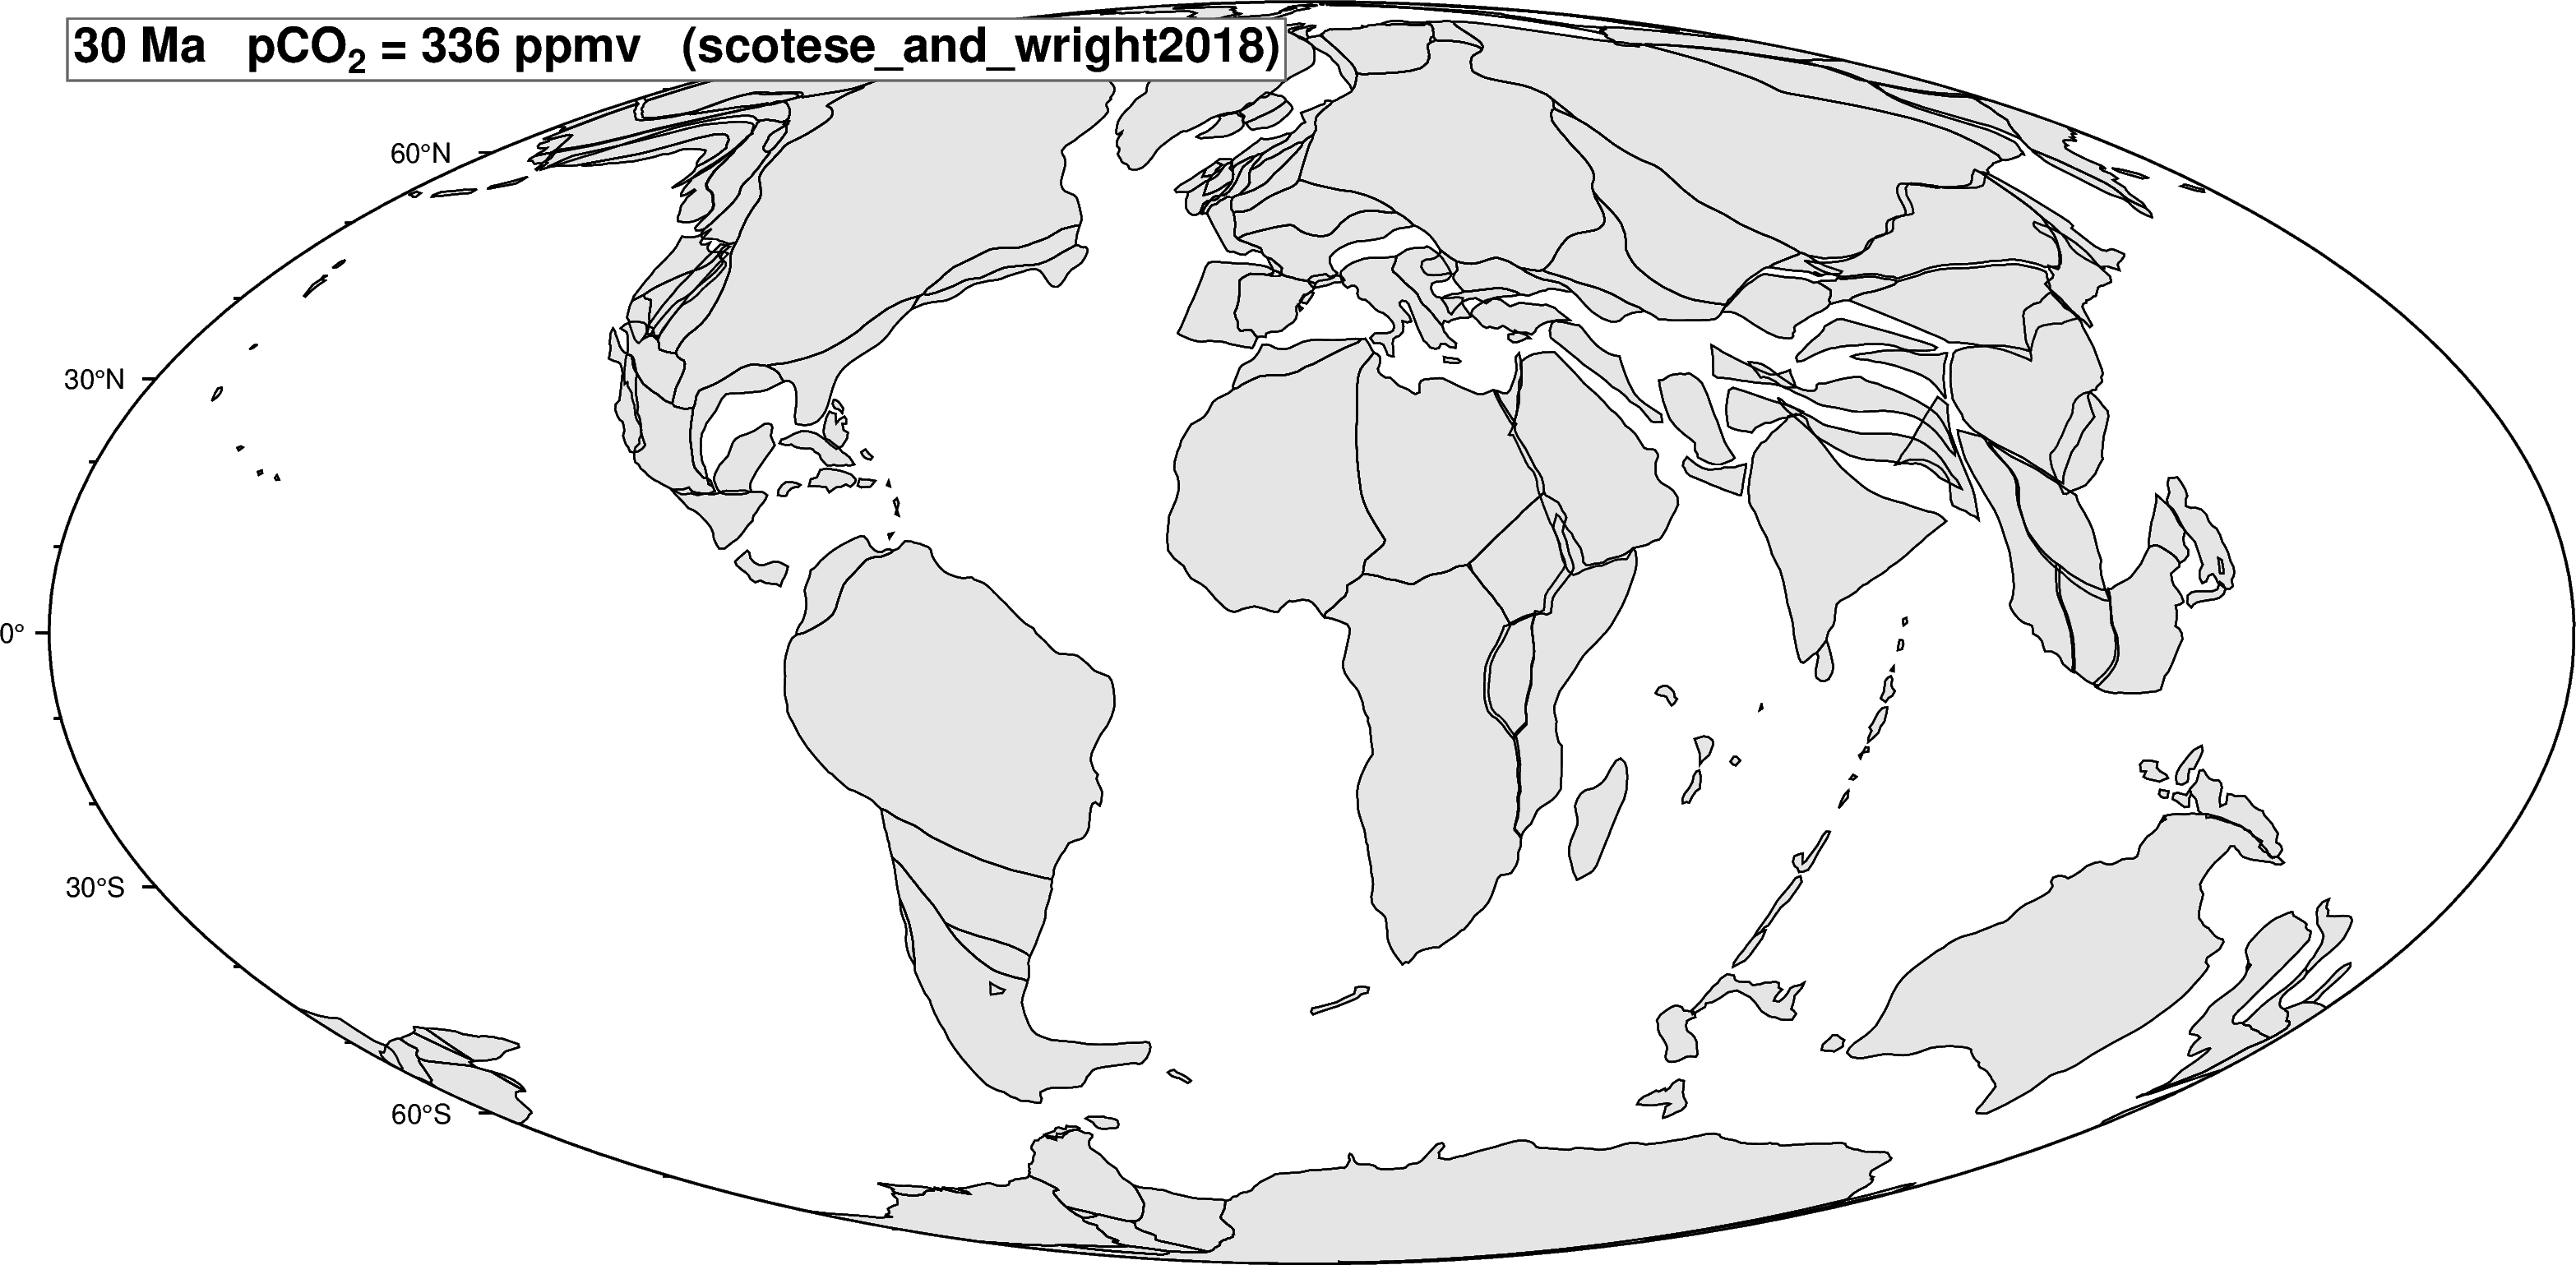

In [8]:
# SET 5: paleo-Earth at inflection ages
display(HTML('<div style="margin-top:1.0cm; padding:0.4em 0.8em; '
              'background:#fde8e8; border-left:5px solid #c14545; '
              'font-size:14pt; font-weight:bold; '
              'font-family:Helvetica,Arial,sans-serif;">'
              'SET 5 — Paleo-Earth at three CO\u2082-inflection ages'
              '</div>'))

pmm   = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons())

def load_paleodem(t_ma):
    """Scotese-Wright paleoDEM Dataset for exactly t_ma, or None.

    Filenames look like 'scotese_wright_paleoDEM_150Ma.nc' or similar; the
    age must be preceded by a word boundary AND followed by 'Ma' so that
    asking for 30 Ma does not accidentally match 130Ma or 300Ma files
    (which a naive '*30*' glob does)."""
    import re
    base = Path(PALEODEM_DIR).expanduser().resolve()
    if not base.exists():
        return None
    target = int(t_ma)
    age_re = re.compile(r"(?:^|[_\-\b])(\d+)\s*Ma\b", re.IGNORECASE)
    for p in sorted(base.glob("*.nc")):
        for m in age_re.finditer(p.name):
            if int(m.group(1)) == target:
                try:
                    print(f"    paleoDEM ({target}Ma): using {p.name}")
                    return xr.open_dataset(p)
                except Exception:
                    pass
    print(f"    paleoDEM ({target}Ma): no exact-age file under {base}")
    return None

for t in INFLECTION_TIMES_MA:
    idx = int(np.argmin(np.abs(age - t)))
    co2_at_t = float(co2[idx])

    # Scotese & Wright 2018 has no Coastlines layer — skip the call entirely
    # to avoid PMM's WARNING noise; ContinentalPolygons outlines are drawn
    # as the first layer below and serve the same visual purpose.
    _coast = None
    if MODEL_NAME != "scotese_and_wright2018":
        try:
            _coast = model.get_coastlines()
        except Exception:
            _coast = None
    gplot = gplately.PlotTopologies(
        plate_reconstruction=recon,
        coastlines=_coast,
        continents=model.get_continental_polygons(),
        COBs=model.get_COBs(),
        time=float(t),
        plot_engine=gplately.PygmtPlotEngine(),
        )

    fig = pygmt.Figure()
    fig.basemap(region="d", projection="W0/26c", frame=["af"])

    dem = load_paleodem(t)
    if dem is not None:
        var = next((v for v in dem.data_vars
                    if any(k in v.lower() for k in ("elev","topo","dem","z"))),
                   list(dem.data_vars)[0])
        elev = dem[var]
        pygmt.makecpt(cmap="oleron", series=[-6000, 6000, 100],
                      background="o", continuous=True)
        fig.grdimage(grid=elev, cmap=True, dpi=150)
        fig.colorbar(frame="a2000f1000+lPaleo-elevation (m)",
                     position="JBC+w14c/0.3c+h+o0/1.2c")
        dem.close()
    else:
        # No PaleoDEM available at this age — fall back to filled continents.
        try:
            fig.plot(data=gplot.get_continents(), pen="0.4p,gray30", fill="gray90")
        except Exception:
            pass

    # Continent OUTLINES drawn on top of the PaleoDEM so the land–ocean
    # boundary is visible against the elevation colour ramp. Outline only
    # (no fill) so the underlying DEM colours stay visible across continents.
    try:
        fig.plot(data=gplot.get_continents(), pen="0.5p,black")
    except Exception:
        pass

    # No plate-boundary backbone — Scotese & Wright 2018 only has evolving
    # topologies for the last 100 Ma, so drawing them for the older two
    # snapshots (250 + 100 Ma) would be empty / misleading.

    fig.text(text=f"{t:.0f} Ma   pCO@-2@- = {co2_at_t:.0f} ppmv   ({MODEL_NAME})",
             position="TL", offset="0.25c/-0.25c", justify="TL",
             font="14p,Helvetica-Bold,black",
             fill="white", pen="0.6p,gray40")
    fig.show(width=1300)
    display(HTML('<div style="height:1.5cm"></div>'))


## What the figures show

**SET 1 (Climate state).** pCO₂'s long-wavelength decline from the early-Phanerozoic high to the present is the principal pySCION signal; ride along the iceline / sea-level panels to see when ice extended equatorward (Late Ord, Late Pal, Cenozoic) and when sea level peaked.

**SET 2 (Atmospheric chemistry + redox).** The Carboniferous–Permian O₂ peak (~30 %), mid-Mesozoic dip, and Cenozoic rebound to modern 21 % dominate the upper-left panel. Cross-reference with the anoxia and vegetation panels for the biotic source of the oxygen.

**SET 3 (Biogeochemical fluxes).** MOCB vs LOCB tells you when the biotic carbon pump moved offshore vs onto land. The carbonate-weathering panel tracks the ocean-acid neutralisation; the silicate-weathering panel tracks the long-term CO₂ thermostat.

**SET 4 (Isotopes).** δ¹³C of A and δ¹³C of marine carbonate burial co-vary on most of the record; departures highlight Permian end-Permian, Triassic-Jurassic, and PETM events. δ³⁴S oscillates over hundreds of Myr in response to pyrite vs gypsum burial.

**SET 5 (Paleo-Earth maps).** The three snapshots ground the four sets of time-series in their paleo-geographic context.

Every panel's y-axis auto-fits to the actual data extent, so you should not see "empty" plots or data running off the top/bottom.


## Extend this

- **Compare against proxy CO₂ compilations.** Overplot Foster/Hönisch/Judd CO₂ proxies on SET 1's CO₂ panel.
- **Swap to other pySCION variants.** Point `PYSCION_REPO` at any local pySCION clone with the same module layout — e.g. a fork with alternative forcings or a different coupling scheme — and re-run.
- **Try another plate model** (e.g. Merdith 2021 or T24's GPMDB-derived frame). Just swap `MODEL_NAME` and accept that the Scotese-Wright PaleoDEMs will no longer coregister with the reconstructed continents.

## References

- **pySCION.** Merdith, A.S., Gernon, T.M., Maffre, P., Donnadieu, Y., Goddéris, Y., Longman, J., Müller, R.D. & Mills, B.J.W. (2025). Phanerozoic icehouse climates as the result of multiple solid-Earth cooling mechanisms. *Science Advances* 11(7), eadm9798. https://doi.org/10.1126/sciadv.adm9798
- Mills, B.J.W., Le Hir, G., Merdith, A., Gurung, K., Bowyer, F.T., Krause, A.J., Sanchez-Baracaldo, P., Hunter, S.J. & Zhang, Y. (2025). Exploring Neoproterozoic climate and biogeochemical evolution in the SCION model. *Global and Planetary Change* 249, 104791. https://doi.org/10.1016/j.gloplacha.2025.104791
- Gurung, K., Mills, B.J.W. (2024). The SCION model — Zenodo 7940113.
- Merdith, A.S. et al. (2021). Extending full-plate tectonic models into deep time. *Earth-Science Reviews* 214, 103477.
- Scotese, C.R. & Wright, N.M. (2018). PaleoDEM resource.
- Mather, B.R. et al. (2024). GPlately. *GDJ* 11, 3–10.
- Tian, D. et al. (2024). PyGMT. *Zenodo*.
- Wessel, P. et al. (2019). GMT 6. *G3* 20, 5556–5564.
